# FRAME

Following install instructions on the [FRAME Github](https://github.com/ShenHaotv/frame)
```
conda create -n frame python=3.11.9
conda activate frame
conda install -c conda-forge numpy==1.26.4 scipy==1.11.4 scikit-learn==1.5.1 -y
conda install -c conda-forge pytest==8.3.4 pyproj==3.6.1 -y
conda install -c conda-forge matplotlib==3.10.0 click==8.1.8 fiona==1.10.1 -y
conda install -c conda-forge cartopy==0.24.1 networkx==3.4.2 -y
pip install git+https://github.com/shenhaotv/frame

# Add the FRAME conda env kernel to jpyter
conda install -c conda-forge ipykernel
python -m ipykernel install --user --name=frame --display-name "FRAME"

# Fix an oops in the code
git clone https://github.com/ShenHaotv/frame.git
pip install -e frame
# Comment out line 49 in frame/digraphstats.py, it looks like a copy/paste error

# On PINKY (Linux Host) I was getting errors launching jupyter lab:
#     jupyter notebook" "No module named 'pysqlite2'
#     _sqlite3.cpython-311-x86_64-linux-gnu.so: undefined symbol: sqlite3_deserialize
# Which turned out to be a version issue with sqlite, which can be fixed like this
conda install -c conda-forge libsqlite=3.46 sqlite=3.46

```

Execution follows the instructions in the [`Example.ipynb`](https://github.com/ShenHaotv/frame/blob/main/docsrc/Example.ipynb)

## FRAME seems to be a bit more resource intensive than FEEMS so we need to use a smaller grid size

In [3]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import importlib.resources as resources
import pandas as pd

from frame.utils import prepare_graph_inputs
from frame.cross_validation import run_cv
from frame import SpatialDiGraph, Vis, Digraphstats
from pathlib import Path

In [51]:
PHYLOGEO_FEEMS_DIR = Path("../../phylogeo-feems")
outer_file = PHYLOGEO_FEEMS_DIR / "hengduan_outer.txt"
grid_path = PHYLOGEO_FEEMS_DIR / "grid/world_triangle_res8.shp"
#grid_path = "/Users/isaac/src/frame/frame/data/grid_110.shp"
graph_file = PHYLOGEO_FEEMS_DIR / "hengduan_grid.gml"

hdm_outer = np.loadtxt(outer_file)
g = nx.read_gml(graph_file)

community_df = pd.read_csv("site_species_matrix.csv", index_col=0)

coords = community_df[["Longitude", "Latitude"]].values
genos = community_df.iloc[:, 1:-2].values
print(genos.shape)

community_df

(208, 320)


,Pedicularis_aff._sigmoidea,Pedicularis_alaschanica,Pedicularis_aloensis,Pedicularis_alopecuros,Pedicularis_altifrontalis,Pedicularis_anas,Pedicularis_angularis,Pedicularis_angustilabris,Pedicularis_angustiloba,Pedicularis_anomala,...,Pedicularis_xiangchengensis,Pedicularis_yanyuanensis,Pedicularis_yaoshanensis,Pedicularis_yui,Pedicularis_yunnanensis,Pedicularis_zayuensis,Pedicularis_zhongdianensis,Pedicularisobliquigaleata,Latitude,Longitude
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,29.325000,95.330000
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,33.990115,95.710000
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,32.912063,95.287500
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,33.716333,99.544173
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,34.569719,99.496906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,26.800000,100.266700
204,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,26.820000,100.230000
205,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,27.517864,99.875994


In [53]:
%%time
outer, edges, grid, _ = prepare_graph_inputs(coord=coords, 
                                             ggrid=grid_path,
                                             buffer=0,
                                             outer=hdm_outer)

CPU times: user 53.6 s, sys: 476 ms, total: 54 s
Wall time: 54.5 s


In [54]:
%%time
sp_digraph = SpatialDiGraph(genos, coords, grid, edges)

CPU times: user 25min 7s, sys: 8min 6s, total: 33min 14s
Wall time: 8min 46s


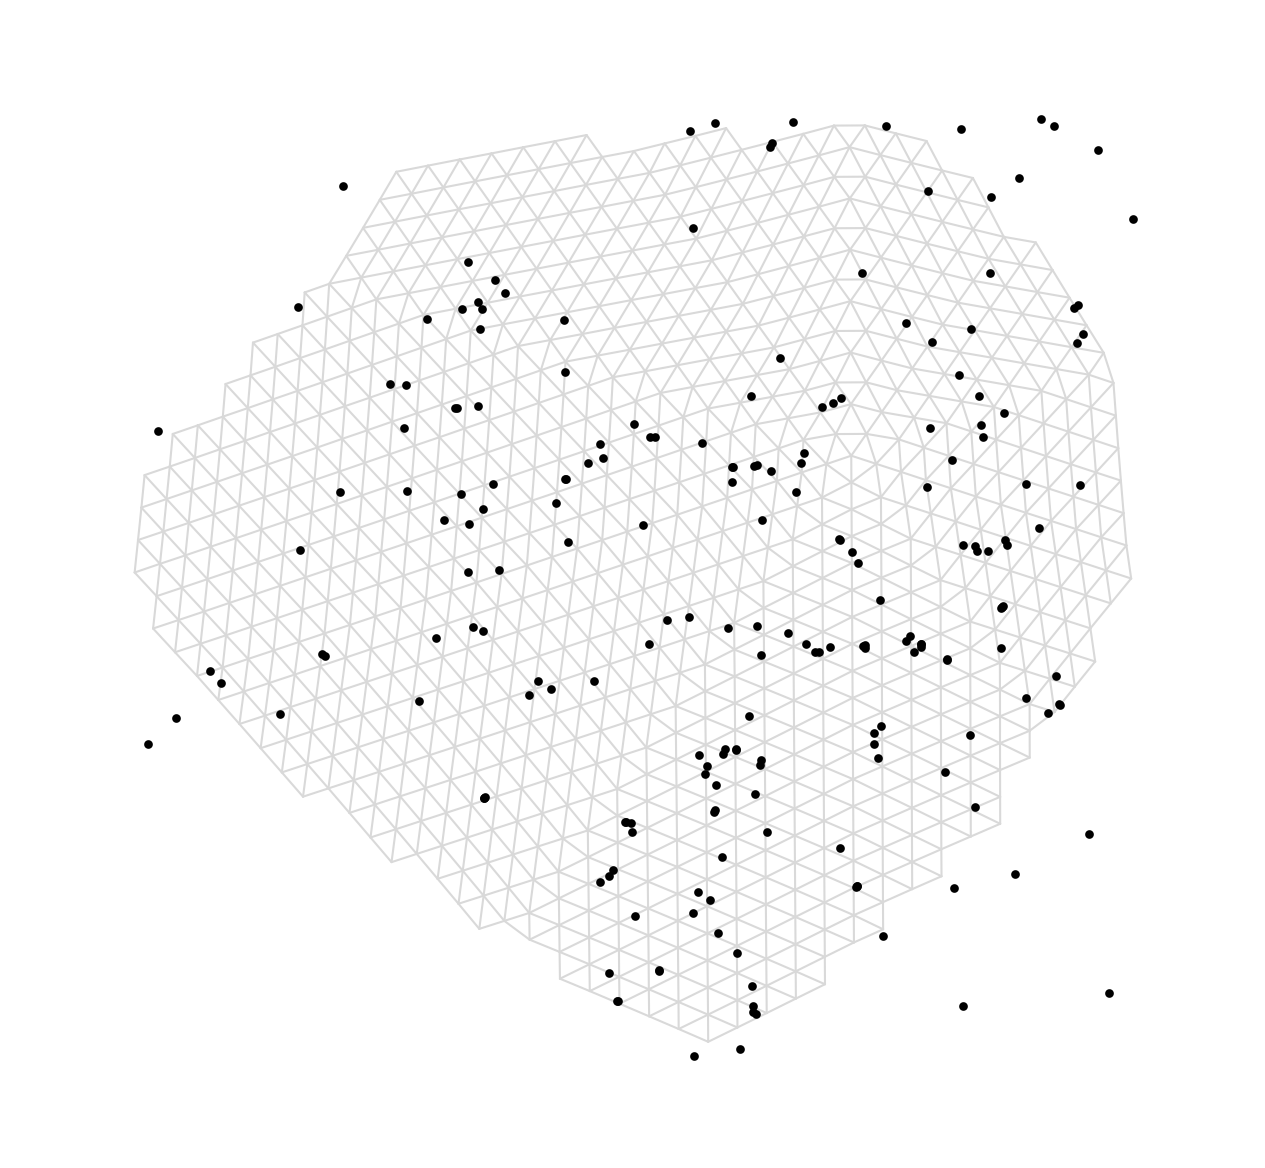

CPU times: user 11.5 s, sys: 2.42 s, total: 14 s
Wall time: 9.03 s


In [55]:
%%time
projection = ccrs.EquidistantConic(central_longitude=100.6897, central_latitude=30.7702)
fig = plt.figure(dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
v = Vis(ax, sp_digraph, projection=projection, edge_width=.5, 
        edge_alpha=1, edge_zorder=200, sample_pt_size=10, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10)
#v.draw_map() <- This doesn't do anything for us because it only draws coastline
v.draw_samples()
v.draw_edges(mode=False)
#v.check_nodes_idx() # <- Do not plot the node ids

plt.show()

In [56]:
%%time
lamb_warmup = 1e3

lamb_grid = np.geomspace(1e-3, 1e3,13)[::-1]

cv,node_train_idxs=run_cv(sp_digraph,
                          lamb_grid,
                          lamb_warmup=lamb_warmup,
                          n_folds=3,
                          factr=1e10,
                          outer_verbose=True,
                          inner_verbose=False,)

if np.argmin(cv)==0:
   lamb_grid_fine=np.geomspace(lamb_grid[0],lamb_grid[1],7)[::-1]

elif np.argmin(cv)==12:
     lamb_grid_fine=np.geomspace(lamb_grid[11],lamb_grid[12], 7)[::-1]
     
else:
    lamb_grid_fine=np.geomspace(lamb_grid[np.argmin(cv)-1],lamb_grid[np.argmin(cv)+1], 7)[::-1]


 fold= 1
CPU times: user 5h 36min 35s, sys: 1h 46min 59s, total: 7h 23min 35s
Wall time: 1h 51min 28s


KeyboardInterrupt: 

In [ ]:
%%time
cv_fine,node_train_idxs_fine=run_cv(sp_digraph,
                                    lamb_grid_fine,
                                    lamb_warmup=lamb_warmup,
                                    n_folds=3,
                                    factr=1e10,
                                    outer_verbose=True,
                                    inner_verbose=False,
                                    node_train_idxs=node_train_idxs)

lamb_opt=lamb_grid_fine[np.argmin(cv_fine)]
lamb_opt=float("{:.3g}".format(lamb_opt))

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(np.log10(lamb_grid), cv, 'bo')  
plt.plot(np.log10(lamb_grid_fine), cv_fine, 'bo')  
plt.xlabel(r"$\mathrm{log}_{10}(\mathrm{\lambda})$")
plt.ylabel('CV Error')

In [57]:
%%time
sp_digraph.fit(lamb=10., factr=1e12)
logm = np.log(sp_digraph.m)
logc = np.log(sp_digraph.c)

#sp_digraph.fit(lamb=10.,
#               factr=1e7,
#               logm_init=logm,
#               logc_init=logc)

lambda=10.0000000, converged in 1 iterations, train_loss=-87594.8320823
CPU times: user 3h 1min 45s, sys: 57min 55s, total: 3h 59min 40s
Wall time: 5h 5min 19s


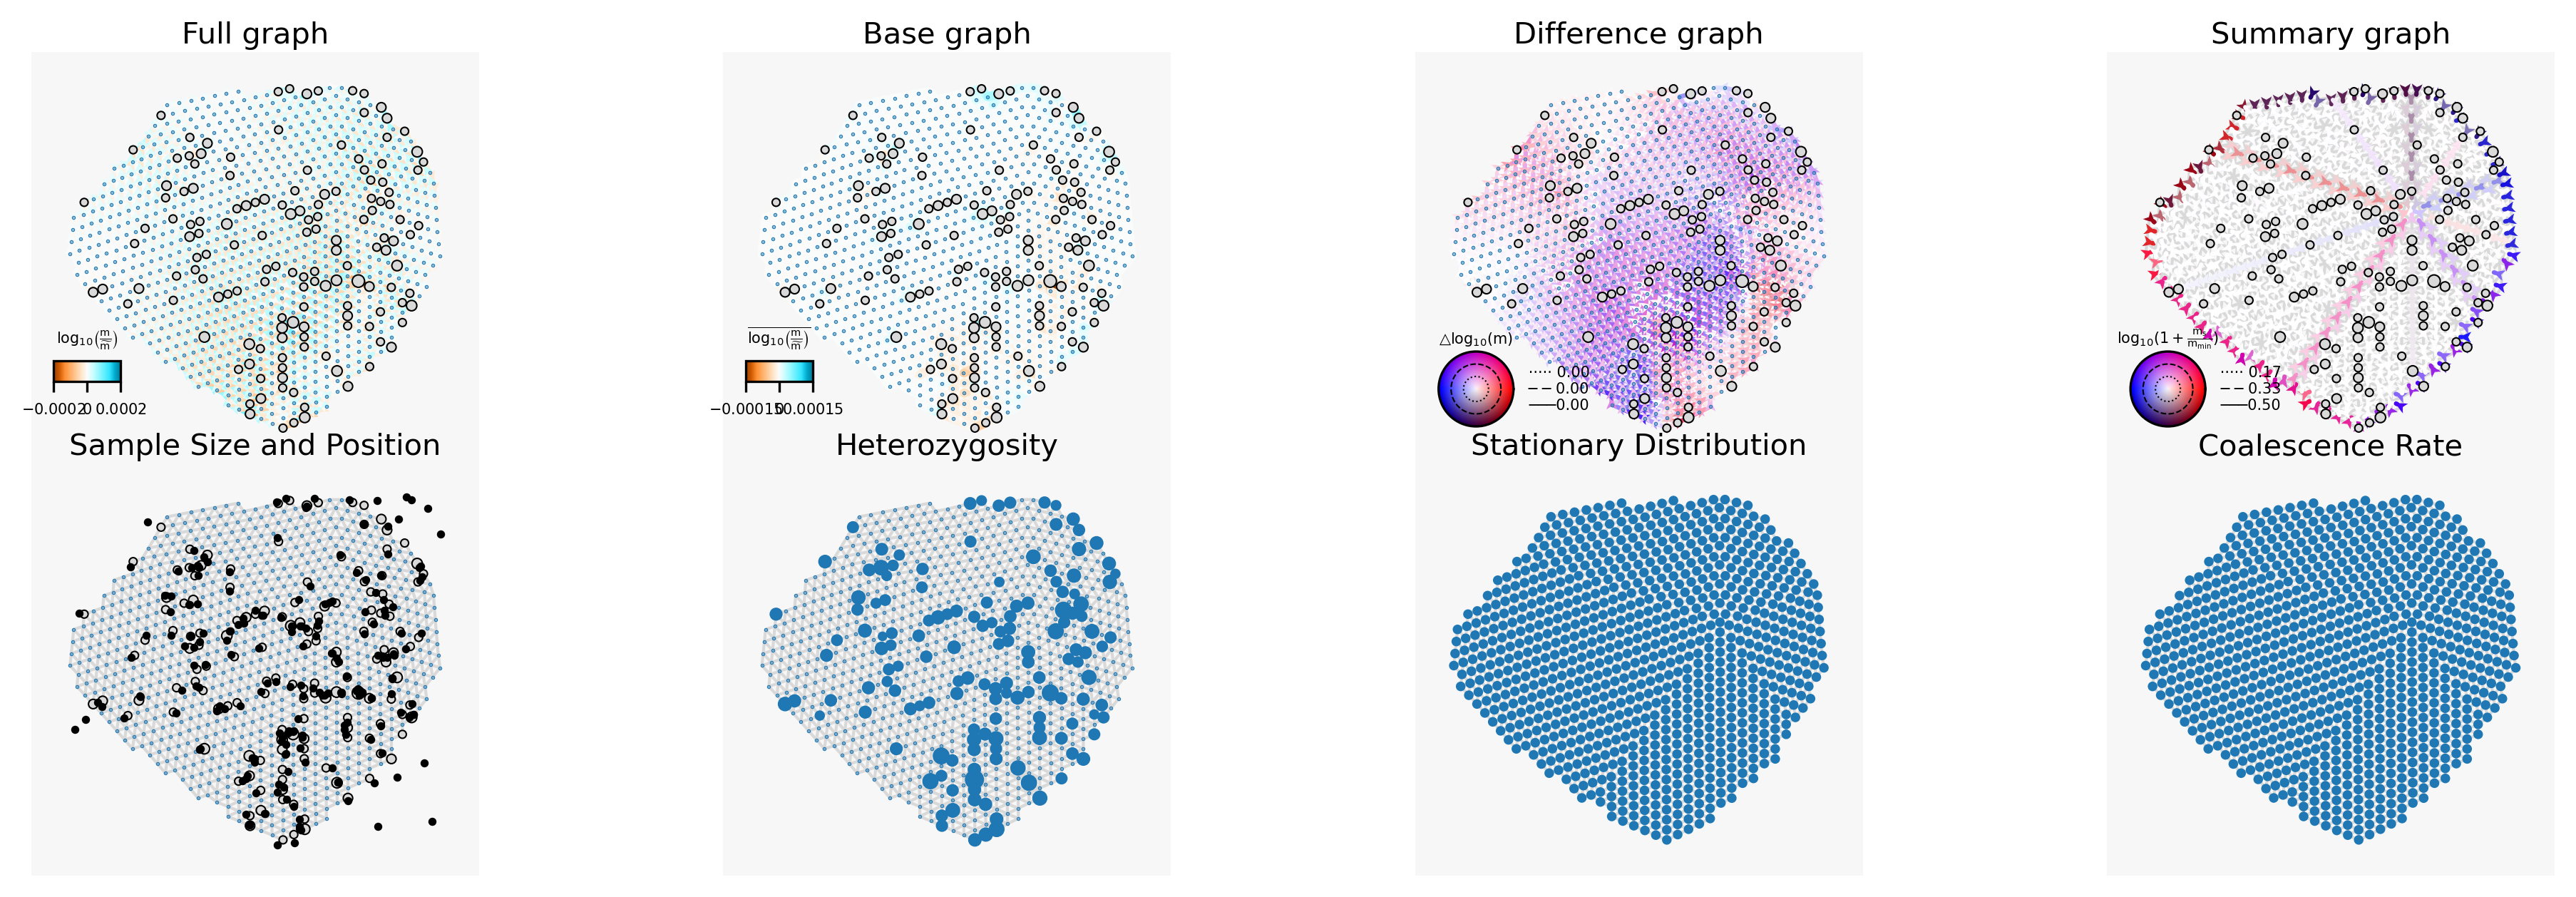

In [58]:
fig, axs= plt.subplots(2, 4, figsize=(16, 5), dpi=300,
                        subplot_kw={'projection': projection})

v = Vis(axs[0,0], sp_digraph, projection=projection, edge_width=1,
        edge_alpha=1, edge_zorder=100, sample_pt_size=20,
        obs_node_size=5, sample_pt_color="black",
        cbar_font_size=5, cbar_ticklabelsize=5, 
        cbar_bbox_to_anchor=(0.05, 0.2), 
        cbar_width="15%",
        cbar_height="5%",
        compass_bbox_to_anchor=(0, 0),
        compass_font_size=5,
        compass_radius=0.2,
        mutation_scale=6)

v.digraph_wrapper(axs, node_scale=[5, 5, 5])
plt.subplots_adjust(hspace=0)

# Using grid110 shp file, and using `buffer=2` instead of `hdm_outer`

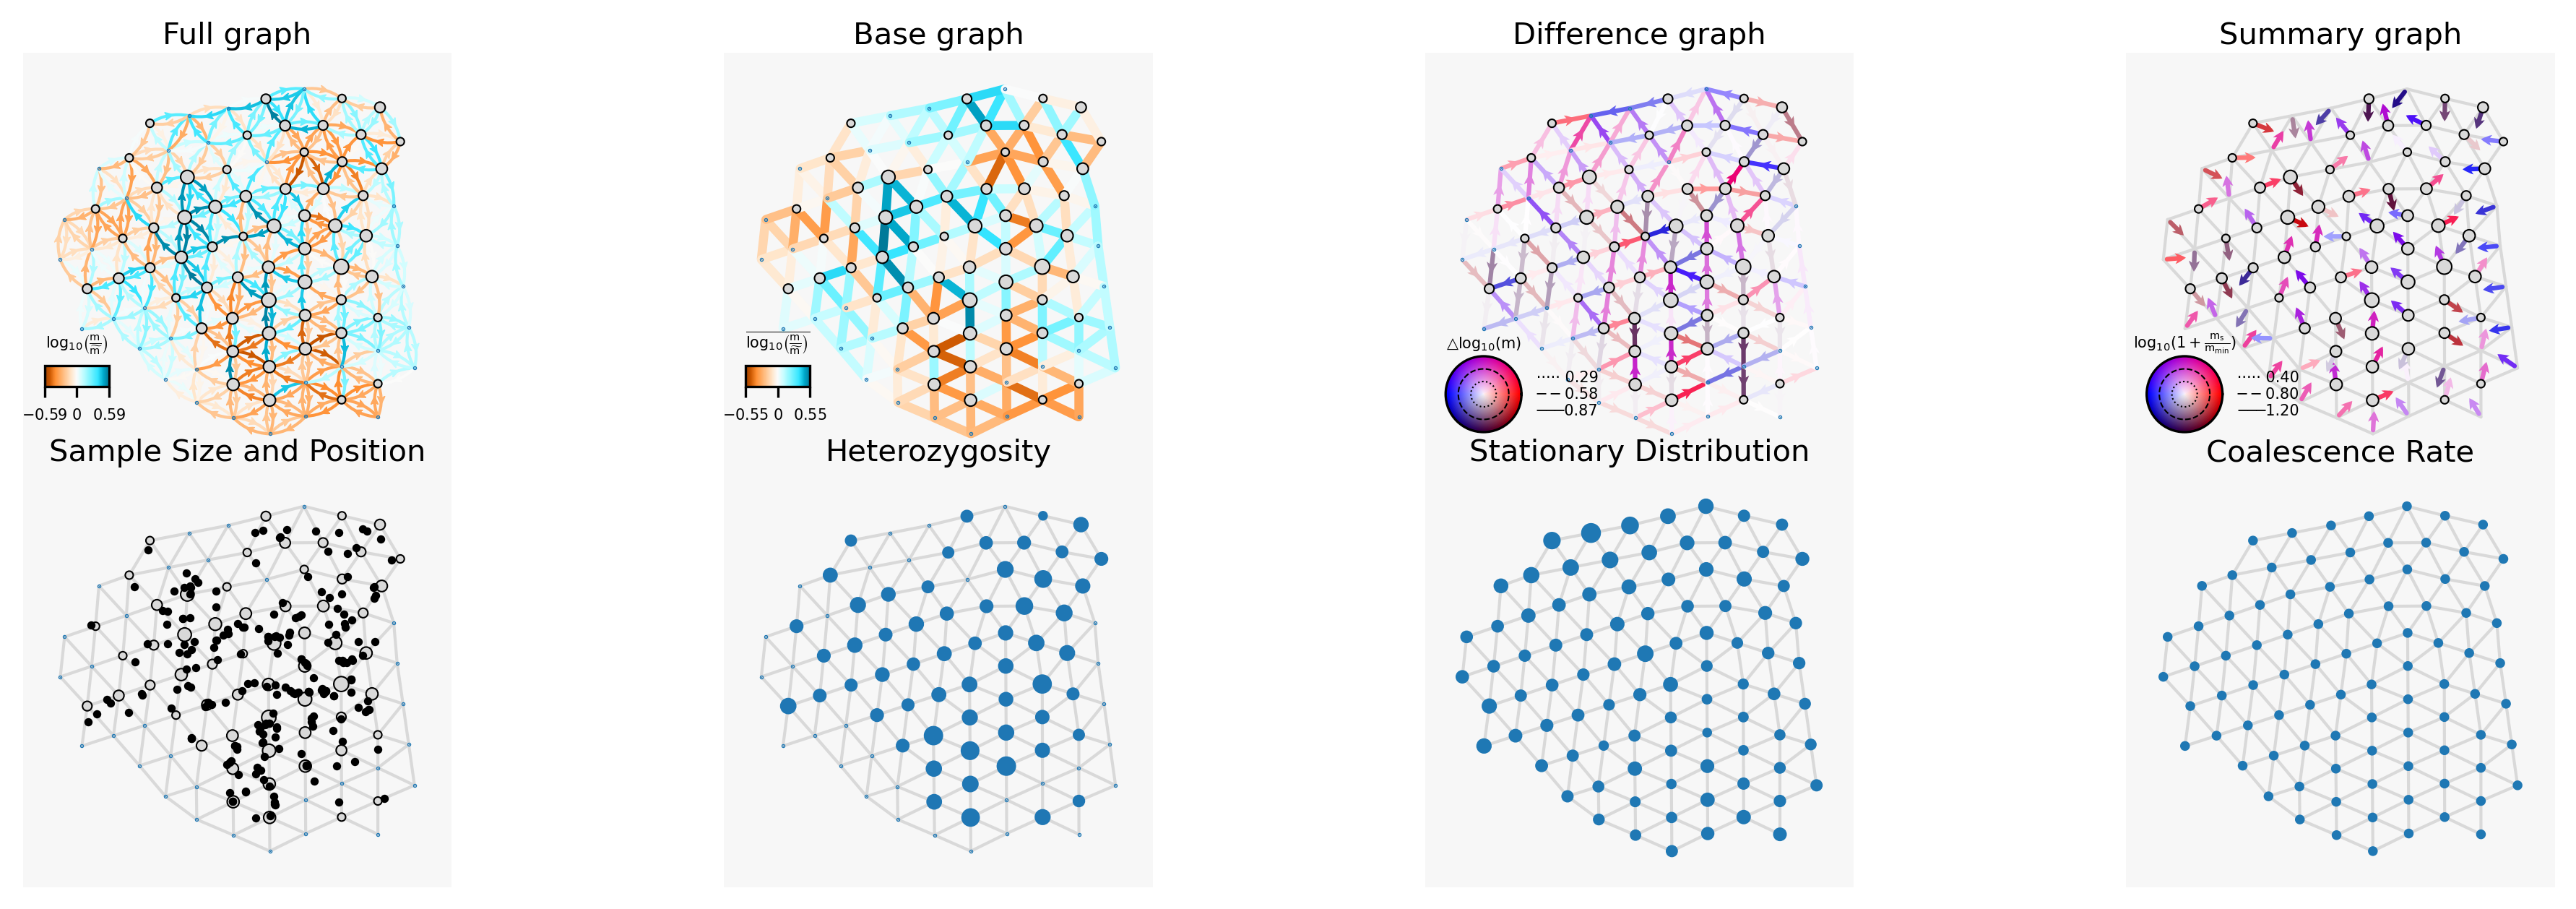

In [39]:
fig, axs= plt.subplots(2, 4, figsize=(16, 5), dpi=300,
                        subplot_kw={'projection': projection})

v = Vis(axs[0,0], sp_digraph, projection=projection, edge_width=1,
        edge_alpha=1, edge_zorder=100, sample_pt_size=20,
        obs_node_size=5, sample_pt_color="black",
        cbar_font_size=5, cbar_ticklabelsize=5, 
        cbar_bbox_to_anchor=(0.05, 0.2), 
        cbar_width="15%",
        cbar_height="5%",
        compass_bbox_to_anchor=(0, 0),
        compass_font_size=5,
        compass_radius=0.2,
        mutation_scale=6)

v.digraph_wrapper(axs, node_scale=[5, 5, 5])
plt.subplots_adjust(hspace=0)

# POPGEN FRAME

In [61]:
%%time
sp = "rhinanth"
coords_file = PHYLOGEO_FEEMS_DIR / f"pedic_feems_files/{sp}_feems_coords.txt"
genos_file = PHYLOGEO_FEEMS_DIR / f"pedic_feems_files/{sp}_feems_genos.npy"
grid_path = PHYLOGEO_FEEMS_DIR / "grid/world_triangle_res8.shp"

coords = np.loadtxt(coords_file)
genos = np.load(genos_file)
print(coords.shape, genos.shape)

outer = np.loadtxt(outer_file)
print(outer.shape)

%%time
outer, edges, grid, _ = prepare_graph_inputs(coord=coords, 
                                             ggrid=grid_path,
                                             buffer=0,
                                             outer=hdm_outer)
print("Done with prepare_graph_inputs")


(72, 2) (72, 14127)
(78, 2)
CPU times: user 3.53 ms, sys: 20 ms, total: 23.5 ms
Wall time: 58.5 ms


UsageError: Line magic function `%%time` not found.


In [62]:
%%time

sp_digraph = SpatialDiGraph(genos, coords, grid, edges)

CPU times: user 26min, sys: 8min 17s, total: 34min 18s
Wall time: 8min 34s


In [ ]:
%%time

sp_digraph.fit(sp_digraph.fit(lamb=10.))

AttributeError: 'SpatialDiGraph' object has no attribute 'pi'

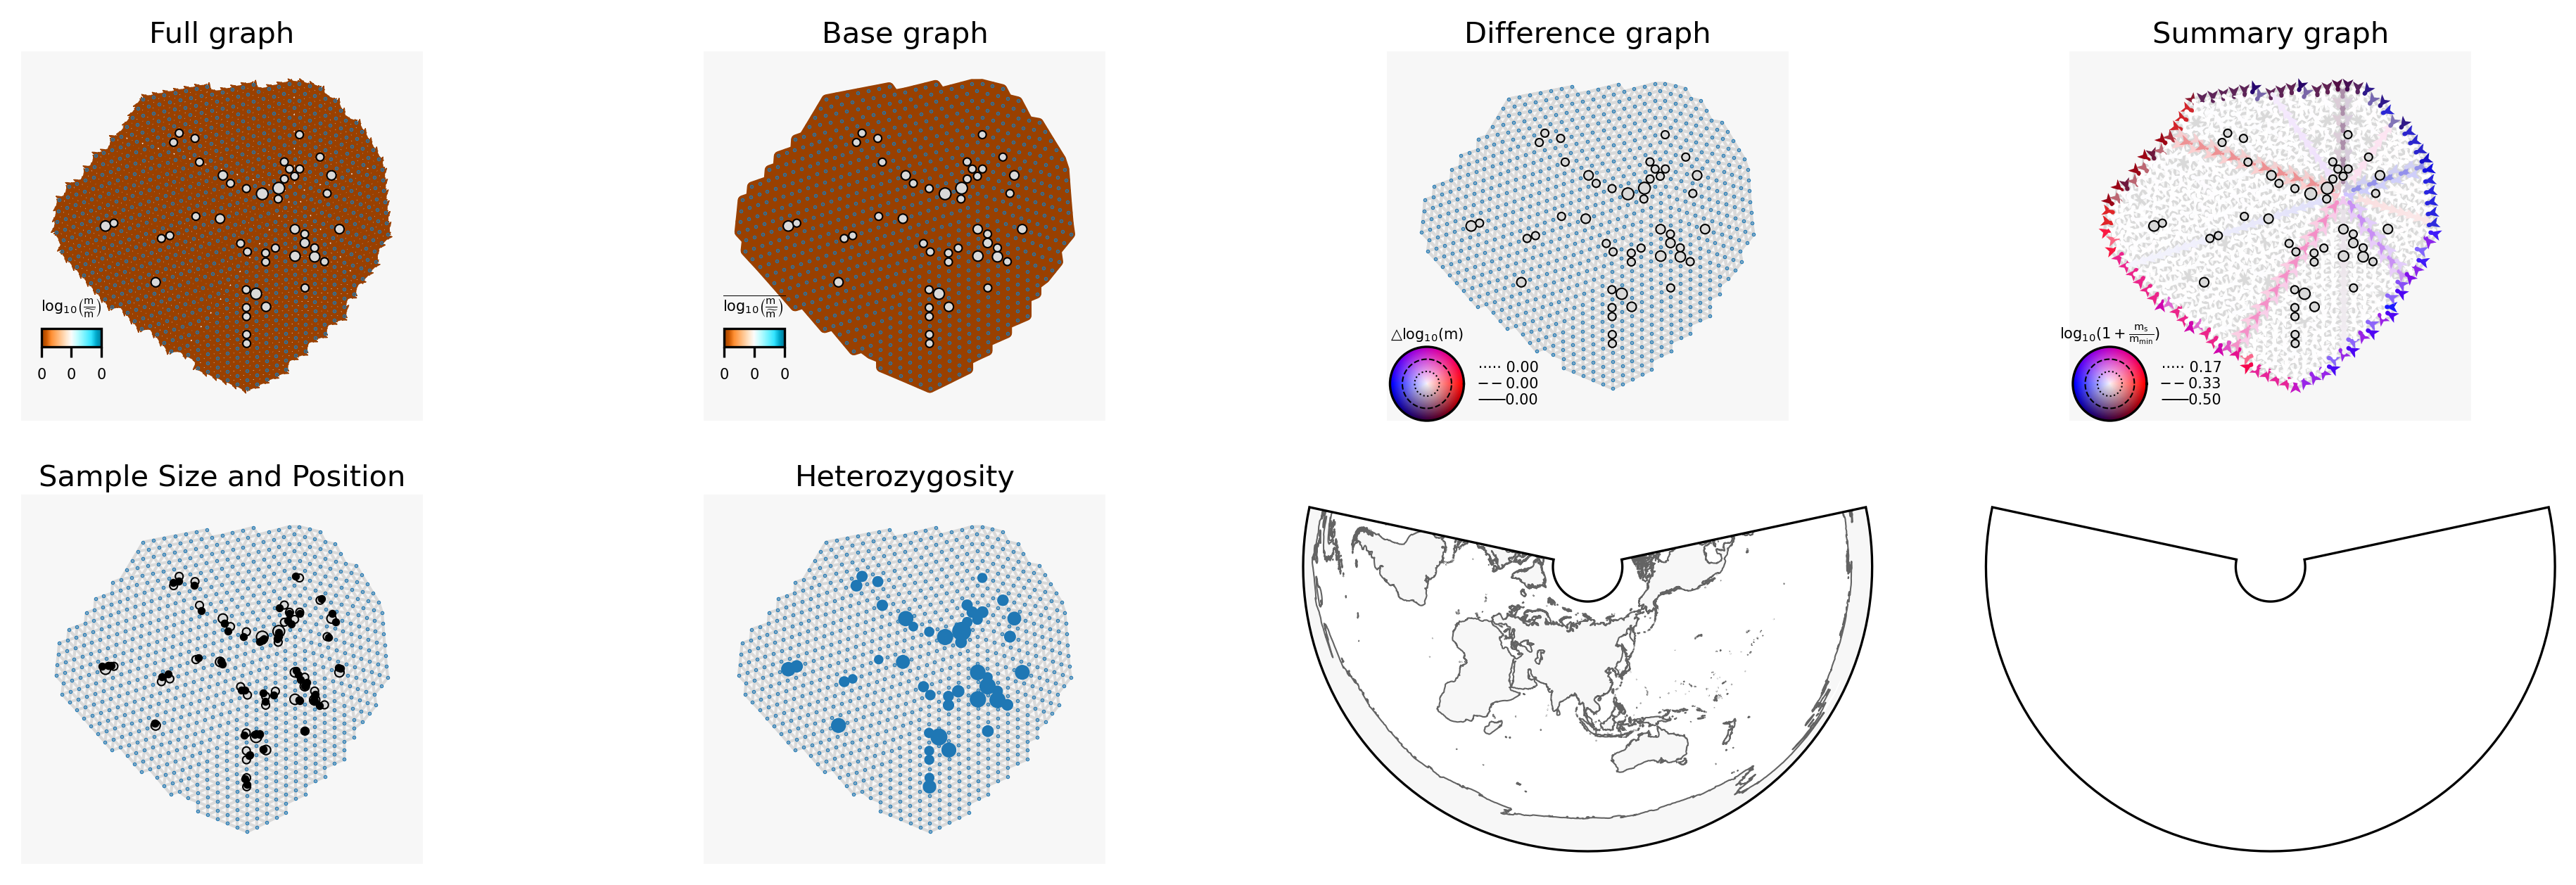

In [64]:
fig, axs= plt.subplots(2, 4, figsize=(16, 5), dpi=300,
                        subplot_kw={'projection': projection})

v = Vis(axs[0,0], sp_digraph, projection=projection, edge_width=1,
        edge_alpha=1, edge_zorder=100, sample_pt_size=20,
        obs_node_size=5, sample_pt_color="black",
        cbar_font_size=5, cbar_ticklabelsize=5, 
        cbar_bbox_to_anchor=(0.05, 0.2), 
        cbar_width="15%",
        cbar_height="5%",
        compass_bbox_to_anchor=(0, 0),
        compass_font_size=5,
        compass_radius=0.2,
        mutation_scale=6)

v.digraph_wrapper(axs, node_scale=[5, 5, 5])
plt.subplots_adjust(hspace=0)
